# Photonic interference beyond 1-WL: three models on the same graphs

This notebook is proposal B of
[rel-int/optyx#16](https://github.com/rel-int/optyx/pull/16): a
*separation* rather than a benchmark. We generate pairs of
non-isomorphic graphs that classical message passing provably cannot
tell apart — the 1-WL bound of
[Xu et al., ICLR 2019](https://arxiv.org/abs/1810.00826) and
[Morris et al., AAAI 2019](https://arxiv.org/abs/1810.02244) — and run
three models on them:

1. **a vanilla GNN**: the textbook isotropic message-passing network —
   one hidden vector per vertex, one shared message function, sum
   aggregation over neighbours, mean readout over vertices;
2. **a MapNN from `discopy.neural`**
   ([discopy/discopy#585](https://github.com/discopy/discopy/pull/585)):
   the same graphs interpreted as interaction maps — the wiring is a
   closed diagram, one shared cell fills every vertex, and the geometry
   of interaction executes the message passing;
3. **an `optyx.interaction.CMap` whose nodes are interferometers with
   coherent memory and coherent messages**: one cell per vertex with a
   `qmode` drive port, one `qmode` message port per incident edge, a
   `qmode` internal memory and a beam-splitter tap into a prediction
   mode. The memory starts in vacuum and one photon is injected through
   the drive of a source vertex at *every* tick, so several photons are
   in flight at once and two-photon interference is part of the readout.

Every readout is invariant under graph isomorphism, so a nonzero
separation on a 1-WL-equivalent pair certifies a graph invariant beyond
1-WL. The experiment code is in
[`examples/beyond_1wl.py`](beyond_1wl.py) and its tests in
`test/test_beyond_1wl.py`.

**Requirements**: models 1 and 2 need `torch`, and model 2 needs the
`discopy.neural` of discopy#585 (available on the discopy branch
`claude/proposal-b-three-models-awc5sc`, which also works for the whole
of optyx). Model 3 runs on optyx's pinned discopy alone.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

import beyond_1wl as b

## The graph pairs, and the 1-WL certificate

The minimal generated pair is two triangles against a hexagon — both
2-regular, so colour refinement assigns identical colours forever. Then
two hexagons against a 12-cycle, the pair proposed in the PR; decalin
against bicyclopentyl, the 10-vertex chemistry pair of
[Sato's survey](https://arxiv.org/abs/2003.04078); and the 4x4 rook's
graph against the Shrikhande graph, strongly regular with the same
parameters srg(16, 6, 2, 2), which even 3-WL cannot separate. The
control pair — a hexagon against a path — is distinguished by 1-WL, so
any model that fails on *it* is broken rather than bounded.

The indistinguishability is asserted, not asserted-in-prose: for every
pair we check that the stable 1-WL colourings agree and that the graphs
are not isomorphic.

In [2]:
for name, (left, right) in b.PAIRS.items():
    left_nx, right_nx = (nx.Graph(
        [(u, v) for u, nbrs in enumerate(graph) for v in nbrs])
        for graph in (left, right))
    print(f"{name:26}  1-WL equivalent: {b.wl_equivalent(left, right)!s:5}"
          f"  isomorphic: {nx.is_isomorphic(left_nx, right_nx)}")
print(f"{'C6 vs P6 (control)':26}  1-WL equivalent: "
      f"{b.wl_equivalent(*b.CONTROL)}")

2C3 vs C6                   1-WL equivalent: True   isomorphic: False
2C6 vs C12                  1-WL equivalent: True   isomorphic: False
decalin vs bicyclopentyl    1-WL equivalent: True   isomorphic: False
rook vs shrikhande          1-WL equivalent: True   isomorphic: False
C6 vs P6 (control)          1-WL equivalent: False


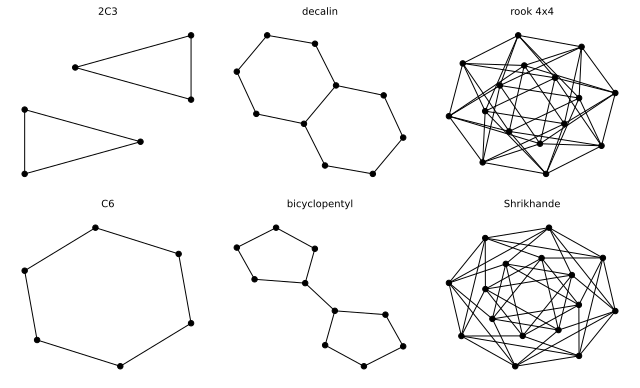

In [3]:
figure, axes = plt.subplots(2, 3, figsize=(9, 5.5))
for axis, (title, graph) in zip(axes.T.flat, [
        ("2C3", b.PAIRS["2C3 vs C6"][0]), ("C6", b.PAIRS["2C3 vs C6"][1]),
        ("decalin", b.PAIRS["decalin vs bicyclopentyl"][0]),
        ("bicyclopentyl", b.PAIRS["decalin vs bicyclopentyl"][1]),
        ("rook 4x4", b.PAIRS["rook vs shrikhande"][0]),
        ("Shrikhande", b.PAIRS["rook vs shrikhande"][1])]):
    edges = nx.Graph([(u, v) for u, ns in enumerate(graph) for v in ns])
    nx.draw_kamada_kawai(edges, ax=axis, node_size=30, node_color="black")
    axis.set_title(title, fontsize=10)
plt.tight_layout()

## Model 1: the vanilla GNN observes the 1-WL bound

The bound is a theorem, but here it is also a measurement. We evaluate
a randomly initialised network — anonymous constant inputs, shared
weights, permutation-invariant readout — and record the largest
difference between the embeddings of the two graphs of each pair, over
independent parameter draws. On 1-WL-equivalent graphs the two
computations perform the same multiset of arithmetic operations, so the
separation is zero to machine precision — below `1e-14` in double
precision, exactly zero for the MapNN, whose compiled interaction also
fixes the summation order — while the control pair separates at every
draw. Training cannot rescue a model
whose forward pass is identically equal on the two classes, so no
training loop is needed for the negative result.

In [4]:
rows = list(b.PAIRS.items())[:3] + [("C6 vs P6 (control)", b.CONTROL)]
for name, (left, right) in rows:
    gap = b.embedding_separation(b.vanilla_gnn_embedding, left, right)
    print(f"{name:26}  max |emb(G1) - emb(G2)| over 5 draws: {gap}")

2C3 vs C6                   max |emb(G1) - emb(G2)| over 5 draws: 2.6645352591003757e-15
2C6 vs C12                  max |emb(G1) - emb(G2)| over 5 draws: 8.881784197001252e-16
decalin vs bicyclopentyl    max |emb(G1) - emb(G2)| over 5 draws: 4.440892098500626e-16
C6 vs P6 (control)          max |emb(G1) - emb(G2)| over 5 draws: 1.3030212397589596


## Model 2: the MapNN observes the same bound

The MapNN pipeline of `discopy.neural` compiles a diagram and one
shared learnable cell per generator name into a global interaction —
the geometry-of-interaction execution formula — and a solver iterates
it. `from_relation` turns each graph into a closed wiring: one `cell`
box per vertex with one `peer` port per neighbour (a permutation
orbit, pooled with `sum`) and a traced `state` loop as its memory.

The wiring is *port-addressed* — each neighbour arrives on its own
wire — but the cell pools its peer orbit with a permutation-invariant
sum and broadcasts one belief, as its signature demands. The whole
model is therefore still anonymous message passing, and lands exactly
on the 1-WL bound. (The `per_leg` emission of `discopy.neural.Site`
answers each port separately; it can produce nonzero separations here,
but they depend on the *ordering* of each adjacency list, which no
graph invariant may do — the same caveat the sudoku comparison of
[discopy#416](https://github.com/discopy/discopy/pull/416) did not
need, because there the ports carried a genuine geometric labelling.)

In [5]:
for name, (left, right) in rows:
    gap = b.embedding_separation(b.mapnn_embedding, left, right)
    print(f"{name:26}  max |emb(G1) - emb(G2)| over 5 draws: {gap}")

2C3 vs C6                   max |emb(G1) - emb(G2)| over 5 draws: 0.0


2C6 vs C12                  max |emb(G1) - emb(G2)| over 5 draws: 0.0


decalin vs bicyclopentyl    max |emb(G1) - emb(G2)| over 5 draws: 0.0
C6 vs P6 (control)          max |emb(G1) - emb(G2)| over 5 draws: 0.5577855706214905


## Model 3: the driven photonic map separates

One `interaction.Box` per vertex: a `qmode` drive port, `degree`
message ports, one coherent `qmode` memory, one prediction. The channel
is a port-symmetric interferometer — the drive and the memory coupled
equally to every message port and to each other, the ports mixed
symmetrically, so the cell is invariant under port permutations and the
readout is a genuine graph invariant (checked below) — followed by a
beam-splitter tap that leaks memory amplitude into a fresh vacuum mode,
the prediction: the input and output couplers of a little cavity. Any
such interferometer decomposes into beam splitters and phase shifters
(Reck et al., PRL 73, 58 (1994)).

The interpretation of a single box is a *stateful channel*: its local
channel with the internal memory fed back to itself with a one-tick
delay. A photon input at every time step is simply `Create(1)` in the
diagram with the feedback loop — the drive is prepared afresh inside
the loop at every tick, the mechanism of `input_state` in `CMap.fix` —
so the driven cell reads its message ports, and writes them back with
the drive reflection and the prediction:

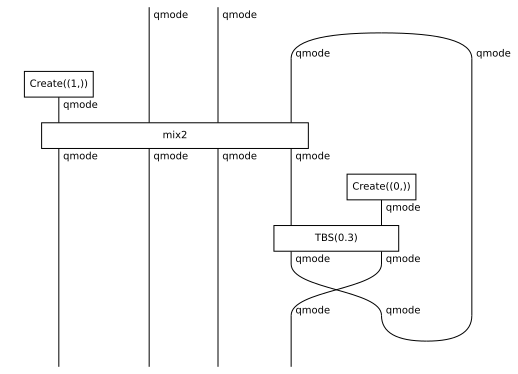

In [6]:
from optyx.photonic import Create

b.stateful_channel(b.vertex_box(2), Create(1)).draw(figsize=(7, 5))

The `CMap` pairs the matching message ports of adjacent vertices; the
drive ports stay unpaired, so the boundary of the map is one `qmode`
per vertex, read from the environment at every tick — the mechanism of
`input_state` in `CMap.fix`. The memory starts in vacuum, and the
protocol is *driven*: one photon enters the drive port of a source
vertex at every tick, so up to `T` photons are in flight, leaving
through the prediction taps and the drive reflections.

The readout per source vertex is two graph-invariant statistics of the
output stream, aggregated over vertices: the mean photon number leaving
at each tick, and the tick-by-tick two-photon coincidences — with
independent single photons on the inputs of a passive network these are
sums of two-by-two permanents of the single-particle transfer matrix,
Hong-Ou-Mandel interference. The transfer matrix iterates the one-photon
block of `CMap.step`'s path matrix; the doubled quimb contraction of
`CMap.unroll` reproduces both statistics to machine precision
(`test_unrolling_matches_the_transfer_matrix`), it is just exponentially
more expensive in the number of output wires.

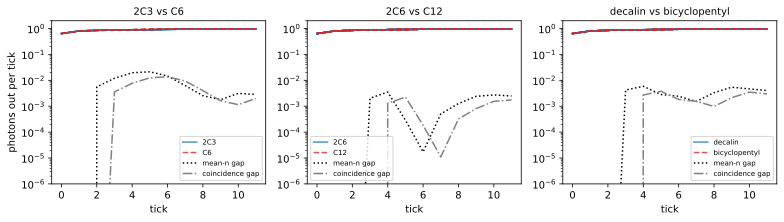

In [7]:
n_ticks = 12
figure, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=False)
for axis, name in zip(axes, list(b.PAIRS)[:3]):
    left, right = b.PAIRS[name]
    profiles = b.profile(left, n_ticks), b.profile(right, n_ticks)
    for graph_rows, style, label in zip(
            profiles, ("-", "--"), name.split(" vs ")):
        for row, curve in enumerate(graph_rows[:, :n_ticks]):
            axis.plot(curve, style, color="C0" if style == "-" else "C3",
                      alpha=.8, label=label if row == 0 else None)
    gap = np.abs(profiles[0] - profiles[1])
    axis.plot(gap[:, :n_ticks].max(axis=0), ":", color="black",
              label="mean-n gap")
    axis.plot(gap[:, n_ticks:].max(axis=0)[:n_ticks], "-.",
              color="gray", label="coincidence gap")
    axis.set_title(name, fontsize=10)
    axis.set_xlabel("tick")
    axis.set_yscale("log"); axis.set_ylim(1e-6, 2)
    axis.legend(fontsize=7)
axes[0].set_ylabel("photons out per tick")
plt.tight_layout()

The output streams of a pair coincide exactly until a photon has had
time to interfere with itself around a cycle, and stay apart from then
on — in the mean photon number and more strongly in the two-photon
coincidences: the separation *is* the interference of closed walks, as
the sum-over-paths reading predicts. Against shot noise: estimating
each per-tick probability to five standard deviations below needs of
order `(5 / margin)^2` runs per source vertex.

In [8]:
for name, (left, right) in list(b.PAIRS.items())[:3]:
    margin = b.separation(left, right, 12)
    print(f"{name:26}  margin: {margin:.5f}   "
          f"shots for 5 sigma: {b.shots_to_separate(margin):,.0f}")
print(f"{'C6 vs P6 (control)':26}  margin: "
      f"{b.separation(*b.CONTROL, 12):.5f}")

2C3 vs C6                   margin: 0.03531   shots for 5 sigma: 20,052


2C6 vs C12                  margin: 0.00991   shots for 5 sigma: 254,768


decalin vs bicyclopentyl    margin: 0.01479   shots for 5 sigma: 114,271


C6 vs P6 (control)          margin: 0.04211


## The controlled ablation: decoherence erases the separation

Running the *same* driven network with the photons measured at every
tick replaces the step's amplitudes by the stochastic matrix of their
squared moduli: classical particles walking through the same wiring,
with the same aggregated readout — and independent, so their
coincidences carry no information beyond the means. It still separates
the control pair — the instrument is not broken — but on every
1-WL-equivalent pair it is *exactly* blind: classical probability mass
moves through a regular graph at rates that depend only on the degrees,
and the aggregate output stream forgets where the mass sits. The
coherent phases that survive aggregation are precisely what the quantum
network adds, and they are the entire separation.

In [9]:
for name, (left, right) in rows:
    gap = b.separation(left, right, 12, decohered=True)
    print(f"{name:26}  decohered separation: {gap}")

2C3 vs C6                   decohered separation: 3.3306690738754696e-16


2C6 vs C12                  decohered separation: 2.220446049250313e-16


decalin vs bicyclopentyl    decohered separation: 3.3306690738754696e-16


C6 vs P6 (control)          decohered separation: 0.009795821537241567


## Invariance, and the limit of one photon

Two checks that keep the claim honest. First, the profile really is a
graph invariant: relabelling the vertices (which also permutes every
adjacency list, hence the port assignment) moves nothing.

In [10]:
decalin = b.PAIRS["decalin vs bicyclopentyl"][0]
relabel = [len(decalin) - 1 - v for v in range(len(decalin))]
relabelled = tuple(
    tuple(sorted(relabel[u] for u in decalin[relabel[v]]))
    for v in range(len(decalin)))
print("relabelling moves the profile by:", np.abs(
    b.profile(decalin, 8) - b.profile(relabelled, 8)).max())

relabelling moves the profile by: 3.3306690738754696e-16


Second, the limit. The rook's graph and the Shrikhande graph are
cospectral, and with several photons in flight the coincidences are
permanental invariants beyond the spectrum — the motivation for the
driven protocol. They still do not separate this pair, and the reason
is sharper than a failed readout. For one and two non-interacting
walkers on strongly regular pairs this is the boundary of
[Gamble et al., PRA 81, 052313 (2010)](https://arxiv.org/abs/1002.3003);
with up to `T` photons in flight their two-particle theorem does not
literally apply, so the notebook measures its way up the orders and
then closes the question for this encoding wholesale: the mean curves
agree, the pairwise coincidences agree, the *third-order* coincidences
agree — and the two single-particle transfer matrices are equal up to a
relabelling of the output wires and a phase on each injection tick.
Every photon-counting probability of non-interacting photons is the
squared modulus of a permanent of a submatrix of the transfer matrix,
and both operations leave those moduli invariant — so the statistics
agree at *every* order, however many photons are injected. (Both graphs
are vertex-transitive — the Shrikhande graph is a Cayley graph — so one
source per graph carries the whole profile.) Crossing this boundary
needs interactions or the measurement-and-feed-forward nonlinearity of
KLM — exactly what a `CMap` tick with classical wires alongside the
quantum ones can express. That experiment needs number-resolved
conditioning inside the loop and is left proposed, not run.

In [11]:
n_ticks = 6
profiles, transfers, third = [], [], []
for graph in b.PAIRS["rook vs shrikhande"]:
    step = b.step_amplitudes(b.graph_cmap(graph))
    matrices = [b.transfer(step, len(graph), source, n_ticks)
                for source in range(len(graph))]
    stats = []
    for matrix in matrices:
        mean, coincidence = b.photon_statistics(matrix, n_ticks)
        stats.append(np.concatenate([
            mean, coincidence[np.triu_indices(n_ticks)]]))
    stats = np.array(stats)
    profiles.append(stats[np.lexsort(np.round(stats, 9).T[::-1])])
    transfers.append(matrices[0])  # vertex-transitive: one source
    third.append(np.sort(
        b.third_order_statistic(matrices[0], n_ticks).ravel()))
left, right = profiles
print("mean-photon separation:   ",
      np.abs(left[:, :n_ticks] - right[:, :n_ticks]).max())
print("two-photon separation:    ",
      np.abs(left[:, n_ticks:] - right[:, n_ticks:]).max())
print("three-photon separation:  ", np.abs(third[0] - third[1]).max())

mean-photon separation:    3.3306690738754696e-16
two-photon separation:     8.326672684688674e-16
three-photon separation:   1.1102230246251565e-16


And the wholesale closure: match the output wires of the two transfer
matrices by their moduli, then check that one column phase per
injection tick accounts for every remaining difference —
`M_shrikhande = P M_rook D` exactly.

In [12]:
first, second = transfers
match_first = np.lexsort(np.round(np.abs(first), 10).T[::-1])
match_second = np.lexsort(np.round(np.abs(second), 10).T[::-1])
rows_first, rows_second = first[match_first], second[match_second]
print("output moduli match:", np.allclose(
    np.abs(rows_first), np.abs(rows_second), atol=1e-10))
for tick in range(n_ticks):
    carried = np.abs(rows_first[:, tick]) > 1e-6
    phases = rows_second[carried, tick] / rows_first[carried, tick]
    assert np.allclose(np.abs(phases), 1, atol=1e-8)
    assert np.allclose(phases, phases[0], atol=1e-8)
print("one phase per injection tick accounts for the rest: True")

output moduli match: True
one phase per injection tick accounts for the rest: True


## What this shows, and what it does not

The three models run on the same graphs with the same
isomorphism-invariant protocol. The two classical models — vanilla and
categorical alike — are exactly constant across every 1-WL-equivalent
pair, as the theory demands; the driven photonic map separates every
non-cospectral pair in its mean output stream and more strongly in its
two-photon coincidences, with margins a photon-counting experiment
resolves in `1e4` to `1e6` shots per source; decohering the same map
erases the separation, so coherence is the resource; and the cospectral
pair marks the limit of *non-interacting* photons — checked order by
order up to three-photon coincidences and then closed at every order at
once, at the level of the transfer matrix itself.

This is a separation on *graph invariants*, related to walk and
interference structure — it is not evidence of learned constraint
propagation, which is proposal A's claim, nor does it make the photonic
map a trainable classifier here: no parameter was trained, because none
needed to be. The next steps proposed in `TODO.md` are the `bit`-wire
CMap (the categorical form of the classical ablation), and the
number-resolved feed-forward tick that could crack rook vs Shrikhande.